<a href="https://colab.research.google.com/github/YASWANTH1817/Api-server/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1 — Install Required Libraries
!pip install shap lime scikit-learn pandas matplotlib seaborn --quiet
print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
shap.initjs()
print("✅ Imports complete!")

✅ Imports complete!


In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, names=col_names)

# Replace 0s with NaN for physiologically invalid zero values
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Diabetic: {df['Outcome'].sum()} | Not Diabetic: {(df['Outcome']==0).sum()}")
df.head()

Dataset shape: (768, 9)
Diabetic: 268 | Not Diabetic: 500


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


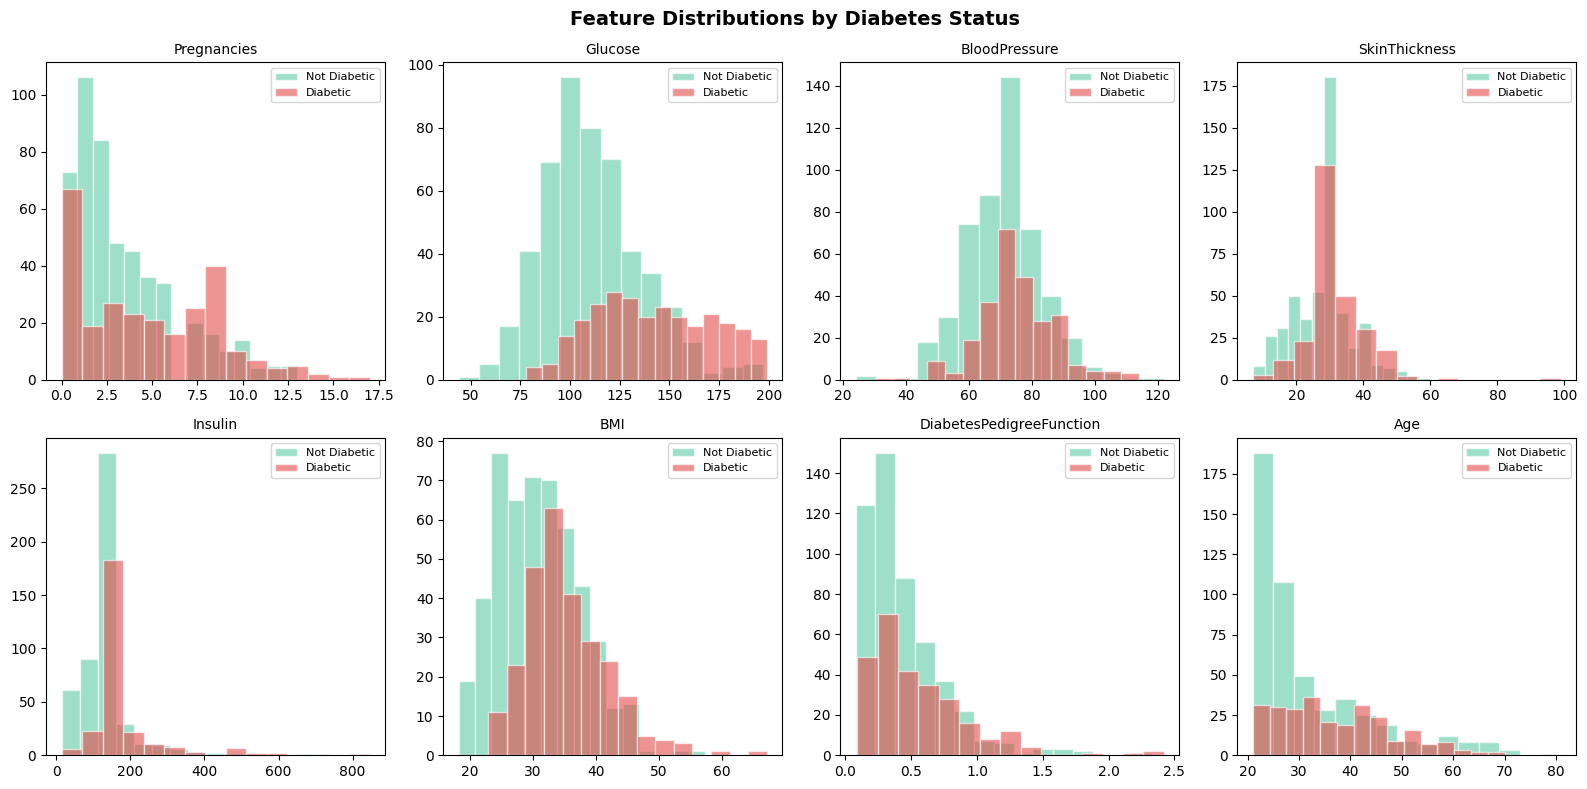

💡 Notice which features differ most between groups — SHAP will confirm this!


In [4]:
# Step 4 — Exploratory Data Analysis (EDA)
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Feature Distributions by Diabetes Status', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), feature_names):
    for val, color, name in [(0,'#5DCAA5','Not Diabetic'), (1,'#E24B4A','Diabetic')]:
        subset = df[df['Outcome'] == val][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print("💡 Notice which features differ most between groups — SHAP will confirm this!")

In [5]:
# Step 5 — Train / Test Split & Model Training
X = df[feature_names].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# STUDENT TASK: Try changing n_estimators (50, 100, 200) and max_depth (None, 5, 10)
model = RandomForestClassifier(
    n_estimators=100,   # <-- change me
    max_depth=None,     # <-- change me
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\n✅ Model Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Diabetic','Diabetic']))

Training samples : 614
Testing  samples : 154

✅ Model Accuracy : 0.7792 (77.9%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



SHAP values shape: (154, 8, 2)


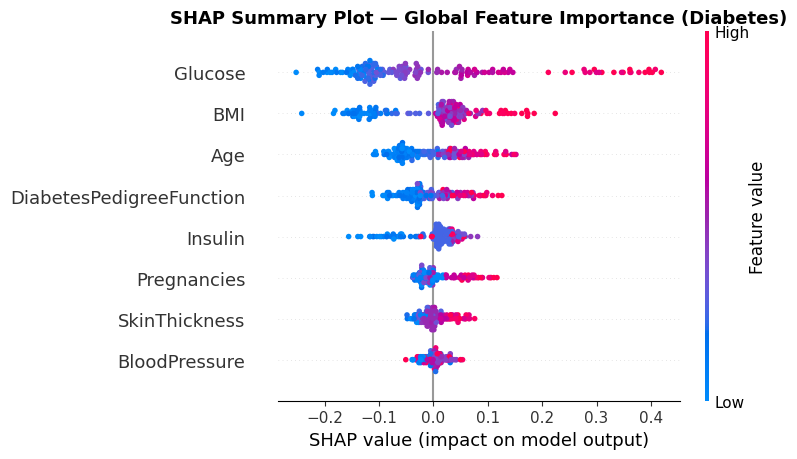

💡 X-axis = SHAP value. Red = high feature value, Blue = low feature value.
💡 Features ranked by mean |SHAP| — most important at top.


In [6]:
# Step 6 — SHAP: Global Feature Importance (Summary / Beeswarm Plot)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (samples, features, classes)
print(f"SHAP values shape: {np.array(shap_values).shape}")

# Handle both old and new SHAP API shapes
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]          # old API: list of arrays
else:
    sv_class1 = shap_values[:, :, 1]    # new API: 3D array

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv_class1,
    X_test,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title('SHAP Summary Plot — Global Feature Importance (Diabetes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 X-axis = SHAP value. Red = high feature value, Blue = low feature value.")
print("💡 Features ranked by mean |SHAP| — most important at top.")

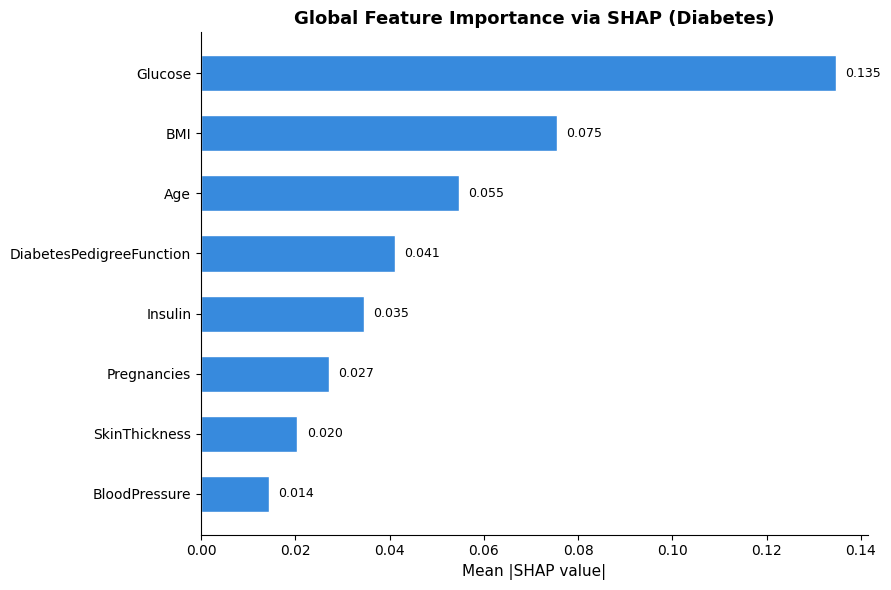


Top 3 most important features:
Feature  Mean |SHAP|
    Age     0.054773
    BMI     0.075481
Glucose     0.134677


In [7]:
# Step 7 — SHAP: Bar Plot (Mean Absolute Importance)
mean_shap = np.abs(sv_class1).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Mean |SHAP|'],
               color='#378ADD', edgecolor='white', height=0.6)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Global Feature Importance via SHAP (Diabetes)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, importance_df['Mean |SHAP|']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(importance_df.tail(3)[['Feature','Mean |SHAP|']].to_string(index=False))

Explaining Patient #0
True Label  : Not Diabetic
Predicted   : Diabetic
Probability : 0.670


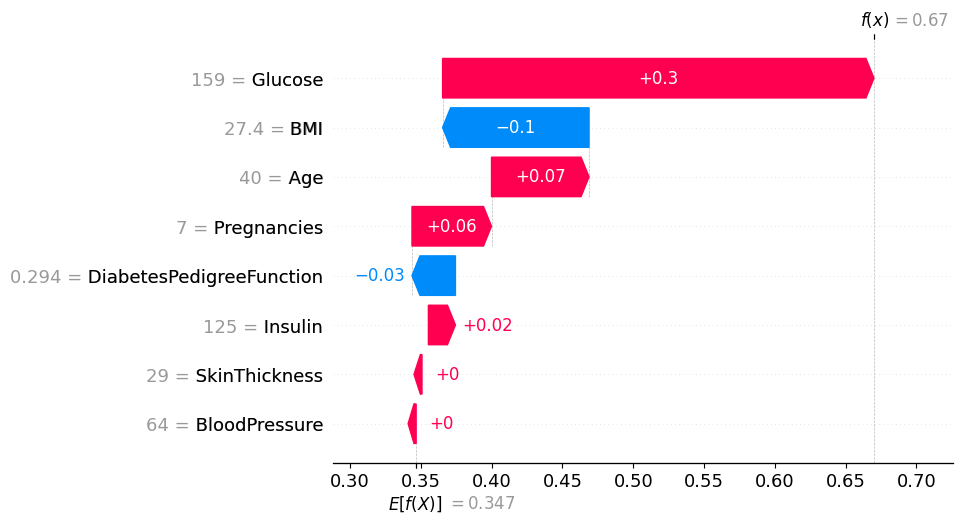


💡 Red bars increase diabetes risk.
💡 Blue bars decrease diabetes risk.


In [11]:
# Step 8 — SHAP Waterfall Plot for a Single Patient

diabetic_indices = np.where(model.predict(X_test) == 1)[0]

if len(diabetic_indices) == 0:
    print("No diabetic patients found.")
else:
    patient_idx = diabetic_indices[0]

    print(f"Explaining Patient #{patient_idx}")
    print(f"True Label  : {'Diabetic' if y_test[patient_idx] == 1 else 'Not Diabetic'}")
    print(f"Predicted   : {'Diabetic' if model.predict(X_test[patient_idx:patient_idx+1])[0] == 1 else 'Not Diabetic'}")
    print(f"Probability : {model.predict_proba(X_test[patient_idx:patient_idx+1])[0][1]:.3f}")

    # Handle expected value safely
    base_val = (
        explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value
    )

    explanation = shap.Explanation(
        values=sv_class1[patient_idx],
        base_values=base_val,
        data=X_test[patient_idx],
        feature_names=feature_names
    )

    shap.waterfall_plot(explanation)

    print("\n💡 Red bars increase diabetes risk.")
    print("💡 Blue bars decrease diabetes risk.")

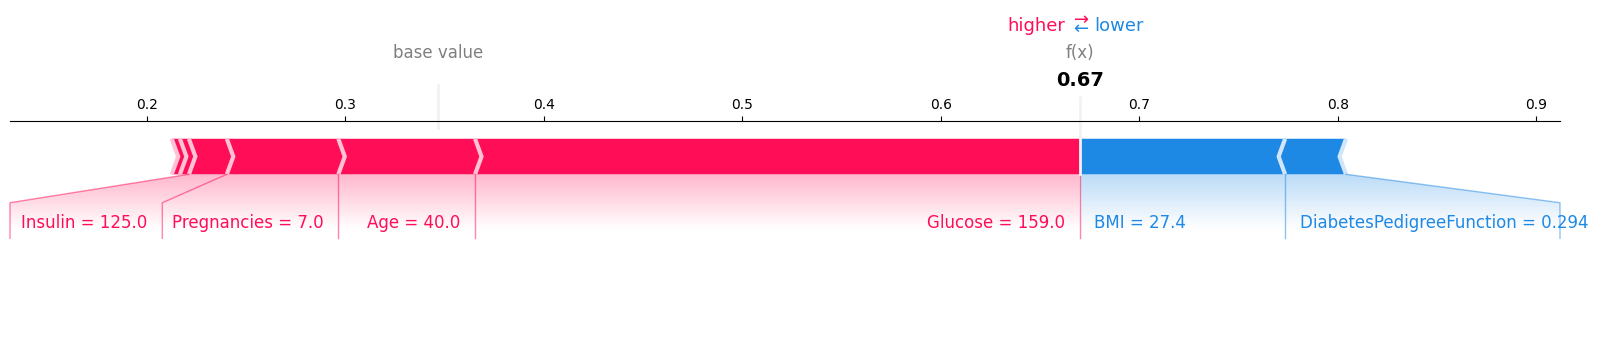


💡 Red features push the prediction toward Diabetic.
💡 Blue features push the prediction toward Not Diabetic.


In [12]:
# Step 9 — SHAP Force Plot for a Single Patient

# Handle expected value safely
base_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

# Generate force plot
shap.force_plot(
    base_val,
    sv_class1[patient_idx],
    X_test[patient_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

print("\n💡 Red features push the prediction toward Diabetic.")
print("💡 Blue features push the prediction toward Not Diabetic.")

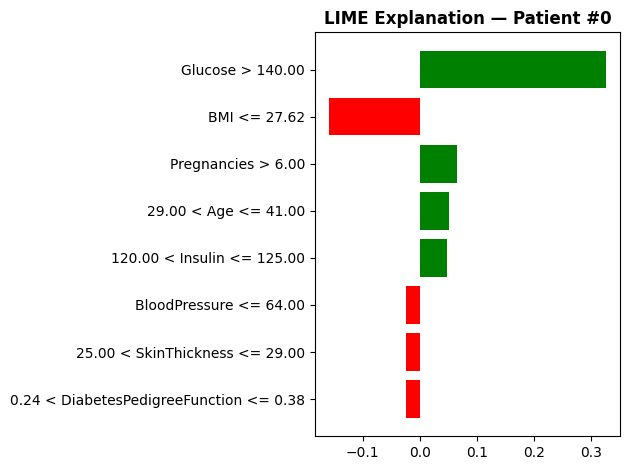


LIME Feature Weights (Diabetic Class):
Glucose > 140.00                          weight=+0.3268  → Diabetic
BMI <= 27.62                              weight=-0.1600  → Not Diabetic
Pregnancies > 6.00                        weight=+0.0645  → Diabetic
29.00 < Age <= 41.00                      weight=+0.0510  → Diabetic
120.00 < Insulin <= 125.00                weight=+0.0478  → Diabetic
BloodPressure <= 64.00                    weight=-0.0251  → Not Diabetic
25.00 < SkinThickness <= 29.00            weight=-0.0239  → Not Diabetic
0.24 < DiabetesPedigreeFunction <= 0.38   weight=-0.0237  → Not Diabetic


In [14]:
# Step 10 — LIME: Local Explanation for a Single Patient

from lime import lime_tabular
import matplotlib.pyplot as plt

# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=['Not Diabetic', 'Diabetic'],
    mode='classification',
    discretize_continuous=True
)

# Explain the selected patient
lime_exp = lime_explainer.explain_instance(
    data_row=X_test[patient_idx],
    predict_fn=model.predict_proba,
    num_features=len(feature_names)
)

# Plot explanation
fig = lime_exp.as_pyplot_figure(label=1)
plt.title(
    f'LIME Explanation — Patient #{patient_idx}',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# Print feature contributions
print("\nLIME Feature Weights (Diabetic Class):")
for feat, weight in sorted(
        lime_exp.as_list(label=1),
        key=lambda x: abs(x[1]),
        reverse=True):

    direction = "→ Diabetic" if weight > 0 else "→ Not Diabetic"
    print(f"{feat:40s}  weight={weight:+.4f}  {direction}")

In [15]:
# Step 12 — LIME: Explain Multiple Patients & Compare
print("LIME explanations for 3 different patients:\n")
sample_indices = [diabetic_indices[0], diabetic_indices[1],
                  np.where(model.predict(X_test) == 0)[0][0]]

for idx in sample_indices:
    exp = lime_explainer.explain_instance(X_test[idx], model.predict_proba, num_features=5)
    pred = model.predict(X_test[idx:idx+1])[0]
    prob = model.predict_proba(X_test[idx:idx+1])[0][1]
    print(f"Patient #{idx} | Pred: {'Diabetic' if pred==1 else 'Not Diabetic'} | P(Diabetic)={prob:.3f}")
    for feat, weight in exp.as_list(label=1):
        print(f"   {feat:38s}  {weight:+.4f}")
    print()

LIME explanations for 3 different patients:

Patient #0 | Pred: Diabetic | P(Diabetic)=0.670
   Glucose > 140.00                        +0.3248
   BMI <= 27.62                            -0.1552
   Pregnancies > 6.00                      +0.0728
   120.00 < Insulin <= 125.00              +0.0456
   29.00 < Age <= 41.00                    +0.0392

Patient #6 | Pred: Diabetic | P(Diabetic)=0.510
   BMI > 36.50                             +0.1307
   99.00 < Glucose <= 117.00               -0.1020
   Age > 41.00                             +0.0841
   Pregnancies > 6.00                      +0.0719
   DiabetesPedigreeFunction <= 0.24        -0.0685

Patient #1 | Pred: Not Diabetic | P(Diabetic)=0.240
   Glucose <= 99.00                        -0.1956
   Insulin <= 120.00                       -0.1134
   Age > 41.00                             +0.0909
   Pregnancies > 6.00                      +0.0755
   0.24 < DiabetesPedigreeFunction <= 0.38  -0.0393

